**Source notebook:** [`06_simses_bess_degradation_demo.ipynb`](../../notebooks/06_simses_bess_degradation_demo.ipynb)


# 06 — SimSES BESS Degradation Demonstration for WEC Smoothing Profiles

This optional final notebook connects selected storage-aware smoothing profiles from [Notebook 05](../outputs/pdf/05_storage_smoothing_metrics.pdf) to a simple stationary battery simulation workflow using SimSES.

The goal is not to optimize BESS sizing, validate a battery lifetime model, or produce a bankable degradation study. Instead, the notebook asks:

> Given selected WEC smoothing duty cycles from Notebook 05, how can they be prepared for battery simulation, and what operation and degradation-relevant indicators can be inspected?

The analysis remains a demonstration. The WEC power signal is still the simplified 250 kW proxy developed earlier in the project, and the selected storage profiles remain smoothing-implied duty cycles rather than optimized BESS dispatch schedules. SimSES is used here as a practical battery-simulation tool to illustrate a possible next step in the workflow, not as final validation of battery lifetime or project design.


## 1. Scope, selected profiles, and simulation concept

This notebook builds on the previous workflow steps:

* [Literature map and research context](../outputs/pdf/00_literature_map.pdf)
* [Wave-resource data preparation](../outputs/pdf/01_wave_data_preparation.pdf)
* [Estimated WEC power from sea-state conditions](../outputs/pdf/02_wec_power_estimation.pdf)
* [Short-term point forecasting baselines](../outputs/pdf/03_forecasting_baselines.pdf)
* [Prediction intervals and uncertainty estimation](../outputs/pdf/04_prediction_intervals_uncertainty.pdf)
* [Storage-aware smoothing metrics](../outputs/pdf/05_storage_smoothing_metrics.pdf)
* SimSES BESS degradation demonstration

The previous notebooks prepared open wave-resource observations, estimated WEC power using a simplified generic power-matrix approach, evaluated short-term point forecasts, calibrated empirical prediction intervals, and converted selected grid-export smoothing rules into storage power, energy, throughput, and equivalent-cycle metrics.

This notebook takes one further optional step. It replays selected storage power profiles through a simple SimSES battery model to inspect battery operation and degradation-relevant outputs under WEC smoothing duty cycles.

The selected cases are limited to the 30 min forecast horizon and 2 h smoothing window:

* observed-power smoothing;
* forecast-informed smoothing.

For consistency with the previous forecasting workflow, the forecast-informed smoothing profile replayed here comes from the Ridge point forecast developed in [Notebook 03](../outputs/pdf/03_forecasting_baselines.pdf). The uncertainty-aware lower-bound smoothing profile from [Notebook 05](../outputs/pdf/05_storage_smoothing_metrics.pdf) was based on the 90% conformal-style prediction intervals developed in [Notebook 04](../outputs/pdf/04_prediction_intervals_uncertainty.pdf), but that additional case is not replayed here so that the battery-simulation demonstration remains compact.

The storage power convention follows Notebook 05:

$p_{st} = p_{wec} - p_{grid}$

where:

* $p_{wec}$ is the estimated WEC power;
* $p_{grid}$ is the selected smoothed grid-export target;
* $p_{st}$ is the storage balancing power.

The sign convention is:

* $p_{st} > 0$: storage charges or absorbs surplus relative to the grid-export target;
* $p_{st} < 0$: storage discharges or supports the grid-export target.

The battery replay is organized in two levels. First, one continuous representative segment is used for detailed time-series inspection. This gives an intuitive view of the storage duty cycle, including charge/discharge switching, state-of-charge movement, cumulative throughput, equivalent cycling, and available SimSES state-of-health outputs.

After the detailed segment replay, the selected fold and segment profiles are replayed independently to summarize operation and stress-related indicators across the evaluation data. Because the rolling-origin folds overlap in calendar time and the continuous segments have different durations, these summaries are not treated as one physical lifetime trajectory. Instead, they are reported using descriptive and duration-normalized indicators such as SOC range, throughput per day, equivalent full cycles per day, C-rate proxies, and available degradation-relevant outputs.

The results should therefore be interpreted as reproducible workflow and screening indicators only. They remain conditional on the simplified WEC power estimate, the smoothing rules, the simple BESS sizing assumptions used here, and the specific SimSES battery model configuration.


In [1]:
import sys
from pathlib import Path

SRC_DIR = Path("../src")

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from bess_replay import plot_replay_distribution_grid

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True


# Paths are relative to the notebooks/ directory.
NOTEBOOK_ID = "notebook_06"

OUTPUTS_DIR = Path("../outputs")

TABLES_DIR = OUTPUTS_DIR / "tables" / NOTEBOOK_ID
FIGURES_DIR = OUTPUTS_DIR / "figures" / NOTEBOOK_ID
NOTEBOOK_OUTPUT_DIR = OUTPUTS_DIR / NOTEBOOK_ID

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


STORAGE_TIMESERIES_PATH = (
    OUTPUTS_DIR
    / "notebook_05"
    / "storage_smoothing_timeseries.parquet"
)

STORAGE_METRICS_SUMMARY_PATH = (
    OUTPUTS_DIR
    / "tables"
    / "notebook_05"
    / "storage_smoothing_metrics_summary.csv"
)

STORAGE_METRICS_BY_FOLD_PATH = (
    OUTPUTS_DIR
    / "tables"
    / "notebook_05"
    / "storage_smoothing_metrics_by_fold.csv"
)

## 2. Inputs from the storage-smoothing notebook

This section loads the storage-smoothing time series and summary tables generated by [Notebook 05](../outputs/pdf/05_storage_smoothing_metrics.pdf). These files contain the smoothed grid-export targets, implied storage balancing power, fold-level metrics, and overall smoothing summaries used for the battery replay demonstration.

In [2]:
storage_timeseries = pd.read_parquet(STORAGE_TIMESERIES_PATH)
storage_metrics_summary = pd.read_csv(STORAGE_METRICS_SUMMARY_PATH)
storage_metrics_by_fold = pd.read_csv(STORAGE_METRICS_BY_FOLD_PATH)

storage_timeseries["target_time"] = pd.to_datetime(storage_timeseries["target_time"])

input_summary = pd.DataFrame(
    [
        ["Storage smoothing time series", STORAGE_TIMESERIES_PATH, len(storage_timeseries)],
        ["Storage metrics summary", STORAGE_METRICS_SUMMARY_PATH, len(storage_metrics_summary)],
        ["Storage metrics by fold", STORAGE_METRICS_BY_FOLD_PATH, len(storage_metrics_by_fold)],
    ],
    columns=["Input", "Path", "Rows"],
)

display(Markdown(input_summary.to_markdown(index=False)))

| Input                         | Path                                                                |   Rows |
|:------------------------------|:--------------------------------------------------------------------|-------:|
| Storage smoothing time series | ../outputs/notebook_05/storage_smoothing_timeseries.parquet         | 166582 |
| Storage metrics summary       | ../outputs/tables/notebook_05/storage_smoothing_metrics_summary.csv |     52 |
| Storage metrics by fold       | ../outputs/tables/notebook_05/storage_smoothing_metrics_by_fold.csv |    260 |

## 3. Selected smoothing profiles

This section selects the two storage-smoothing profiles used in the battery replay demonstration. Both profiles use the 30 min forecast horizon and the 2 h smoothing window from [Notebook 05](../outputs/pdf/05_storage_smoothing_metrics.pdf).

The two selected cases are:

* observed-power smoothing;
* forecast-informed smoothing.

The fold-level metrics are used to define conservative battery sizing assumptions later in the notebook. In particular, the battery power and usable-energy requirements are taken from the maximum values across folds rather than from fold-averaged values.

In [3]:
SELECTED_HORIZON_STEPS = 1
SELECTED_SMOOTHING_WINDOW_MIN = 120
SELECTED_SCENARIOS = ["B", "C"]

selected_timeseries = storage_timeseries[
    (storage_timeseries["horizon_steps"] == SELECTED_HORIZON_STEPS)
    & (storage_timeseries["smoothing_window_min"] == SELECTED_SMOOTHING_WINDOW_MIN)
    & (storage_timeseries["scenario"].isin(SELECTED_SCENARIOS))
].copy()

selected_metrics_by_fold = storage_metrics_by_fold[
    (storage_metrics_by_fold["horizon_steps"] == SELECTED_HORIZON_STEPS)
    & (storage_metrics_by_fold["smoothing_window_min"] == SELECTED_SMOOTHING_WINDOW_MIN)
    & (storage_metrics_by_fold["scenario"].isin(SELECTED_SCENARIOS))
].copy()

selected_summary = (
    selected_metrics_by_fold
    .groupby(["scenario", "scenario_name"], observed=True)
    .agg(
        n_folds=("fold_id", "nunique"),
        max_storage_power_rating_kw=("storage_power_rating_kw", "max"),
        max_required_usable_energy_kwh=("required_energy_kwh", "max"),
        mean_throughput_kwh=("throughput_kwh", "mean"),
        mean_equivalent_full_cycles=("equivalent_full_cycles", "mean"),
        mean_ramp_p95_reduction_percent=("ramp_p95_reduction_percent", "mean"),
    )
    .reset_index()
)

selected_summary["scenario"] = pd.Categorical(
    selected_summary["scenario"],
    categories=SELECTED_SCENARIOS,
    ordered=True,
)

selected_summary = (
    selected_summary
    .sort_values("scenario")
    .reset_index(drop=True)
)

selected_summary_display = selected_summary.copy()

numeric_cols = selected_summary_display.select_dtypes(include="number").columns
selected_summary_display[numeric_cols] = selected_summary_display[numeric_cols].round(2)

selected_summary_display.columns = (
    selected_summary_display.columns
    .str.replace("_", " ", regex=False)
)

display(Markdown(selected_summary_display.to_markdown(index=False)))

| scenario   | scenario name               |   n folds |   max storage power rating kw |   max required usable energy kwh |   mean throughput kwh |   mean equivalent full cycles |   mean ramp p95 reduction percent |
|:-----------|:----------------------------|----------:|------------------------------:|---------------------------------:|----------------------:|------------------------------:|----------------------------------:|
| B          | Observed-power smoothing    |         5 |                         31.39 |                            62.83 |                890.81 |                          8.44 |                             70.53 |
| C          | Forecast-informed smoothing |         5 |                         41.41 |                           225.38 |               1685.04 |                          4.17 |                             81.21 |

## 4. Representative continuous replay segment

Before running the battery simulation, one continuous segment is selected for detailed time-series inspection. This segment is used to show the battery operation more intuitively than a collection of short independent replays.

The selected segment is taken from the same 30 min horizon and 2 h smoothing-window profiles defined above. It is used for both selected smoothing cases so that the observed-power and forecast-informed profiles can be compared over the same time period.

The purpose of this detailed segment is to inspect the storage duty cycle, SOC movement, cumulative throughput, equivalent cycling, and available SimSES degradation-relevant outputs under a continuous WEC smoothing period. The later cross-segment summary will then replay all selected fold/segment profiles independently and report duration-normalized indicators.

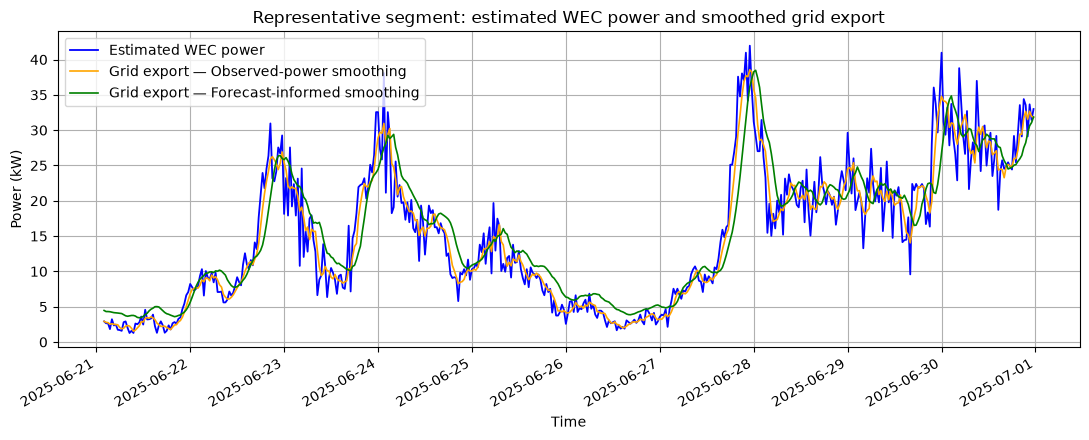

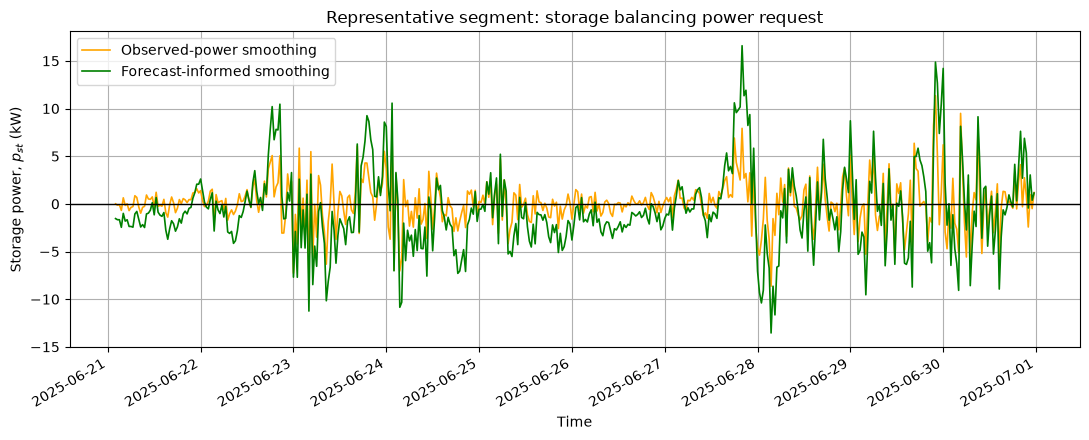

Saved representative-segment figures:

* `../outputs/figures/notebook_06/representative_segment_grid_power.png`
* `../outputs/figures/notebook_06/representative_segment_storage_power.png`

| scenario   | scenario name               | start time          | end time            |   n samples |   duration hours |   duration days |   max abs storage power kw |   required energy kwh |   throughput kwh |
|:-----------|:----------------------------|:--------------------|:--------------------|------------:|-----------------:|----------------:|---------------------------:|----------------------:|-----------------:|
| B          | Observed-power smoothing    | 2025-06-21 02:00:00 | 2025-06-30 23:30:00 |         476 |              238 |            9.92 |                      11.35 |                 36.05 |           412.3  |
| C          | Forecast-informed smoothing | 2025-06-21 02:00:00 | 2025-06-30 23:30:00 |         476 |              238 |            9.92 |                      16.59 |                189.64 |           751.36 |

In [4]:
TIME_STEP_HOURS = 0.5

REPRESENTATIVE_FOLD_ID = 5
REPRESENTATIVE_SEGMENT_ID = "h1_fold5_seg5"

SCENARIO_COLOR_MAP = {
    "B": "orange",
    "C": "green",
}

representative_segment = selected_timeseries[
    (selected_timeseries["fold_id"] == REPRESENTATIVE_FOLD_ID)
    & (selected_timeseries["segment_id"] == REPRESENTATIVE_SEGMENT_ID)
].copy()

if representative_segment.empty:
    raise ValueError(
        "The selected representative segment was not found in the selected time series."
    )

if representative_segment["scenario"].nunique() != len(SELECTED_SCENARIOS):
    raise ValueError(
        "The representative segment does not contain all selected smoothing scenarios."
    )

representative_segment = representative_segment.sort_values(
    ["scenario", "target_time"]
).reset_index(drop=True)


# Plot WEC power and smoothed grid-export targets.
fig, ax = plt.subplots(figsize=(11, 4.5))

wec_reference = (
    representative_segment
    .drop_duplicates(subset=["target_time"])
    .sort_values("target_time")
)

ax.plot(
    wec_reference["target_time"],
    wec_reference["p_wec_kw"],
    linewidth=1.3,
    color="blue",
    label="Estimated WEC power",
)

for scenario, scenario_df in representative_segment.groupby(
    "scenario",
    observed=True,
):
    scenario_df = scenario_df.sort_values("target_time")
    scenario_name = scenario_df["scenario_name"].iloc[0]

    ax.plot(
        scenario_df["target_time"],
        scenario_df["p_grid_kw"],
        linewidth=1.2,
        color=SCENARIO_COLOR_MAP[scenario],
        label=f"Grid export — {scenario_name}",
    )

ax.set_title("Representative segment: estimated WEC power and smoothed grid export")
ax.set_xlabel("Time")
ax.set_ylabel("Power (kW)")
ax.legend(loc="best")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

grid_power_plot_path = FIGURES_DIR / "representative_segment_grid_power.png"
fig.savefig(grid_power_plot_path, dpi=300, bbox_inches="tight")
plt.show()


# Plot storage balancing power request.
fig, ax = plt.subplots(figsize=(11, 4.5))

for scenario, scenario_df in representative_segment.groupby(
    "scenario",
    observed=True,
):
    scenario_df = scenario_df.sort_values("target_time")
    scenario_name = scenario_df["scenario_name"].iloc[0]

    ax.plot(
        scenario_df["target_time"],
        scenario_df["p_st_kw"],
        linewidth=1.2,
        color=SCENARIO_COLOR_MAP[scenario],
        label=scenario_name,
    )

ax.axhline(0, linewidth=1.0, color="black")
ax.set_title("Representative segment: storage balancing power request")
ax.set_xlabel("Time")
ax.set_ylabel("Storage power, $p_{st}$ (kW)")
ax.legend(loc="best")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

storage_power_plot_path = FIGURES_DIR / "representative_segment_storage_power.png"
fig.savefig(storage_power_plot_path, dpi=300, bbox_inches="tight")
plt.show()


display(
    Markdown(
        "Saved representative-segment figures:\n\n"
        f"* `{grid_power_plot_path}`\n"
        f"* `{storage_power_plot_path}`"
    )
)


representative_segment_summary = (
    representative_segment
    .groupby(["scenario", "scenario_name"], observed=True)
    .agg(
        start_time=("target_time", "min"),
        end_time=("target_time", "max"),
        n_samples=("target_time", "size"),
        max_abs_storage_power_kw=("abs_storage_power_kw", "max"),
        required_energy_kwh=("required_energy_kwh", "max"),
        throughput_kwh=("abs_storage_power_kw", lambda s: s.sum() * TIME_STEP_HOURS),
    )
    .reset_index()
)

representative_segment_summary["duration_hours"] = (
    representative_segment_summary["n_samples"] * TIME_STEP_HOURS
)

representative_segment_summary["duration_days"] = (
    representative_segment_summary["duration_hours"] / 24
)

representative_segment_summary = representative_segment_summary[
    [
        "scenario",
        "scenario_name",
        "start_time",
        "end_time",
        "n_samples",
        "duration_hours",
        "duration_days",
        "max_abs_storage_power_kw",
        "required_energy_kwh",
        "throughput_kwh",
    ]
]

representative_segment_display = representative_segment_summary.copy()

numeric_cols = representative_segment_display.select_dtypes(include="number").columns
representative_segment_display[numeric_cols] = (
    representative_segment_display[numeric_cols].round(2)
)

representative_segment_display.columns = (
    representative_segment_display.columns
    .str.replace("_", " ", regex=False)
)

display(Markdown(representative_segment_display.to_markdown(index=False)))

## 5. Simple BESS sizing assumptions

This section defines simple battery-size assumptions for the SimSES replay. The sizing is derived directly from the selected storage-smoothing metrics rather than optimized.

For each selected smoothing case, the battery power rating is based on the maximum storage power requirement across the five rolling-origin folds. The usable energy requirement is also based on the maximum fold-level energy requirement. This keeps the replay conservative relative to the selected evaluation folds.

The assumed SOC operating window is 20–80%. Therefore, the nominal battery energy capacity is larger than the usable energy requirement. The rounded values below are used only to create simple scenario-specific battery configurations for the demonstration.

These assumptions should not be interpreted as optimized BESS sizing. They are transparent replay assumptions for comparing battery operation under the selected WEC smoothing duty cycles.


In [5]:
SOC_MIN = 0.20
SOC_MAX = 0.80
SOC_REFERENCE = 0.50

USABLE_SOC_FRACTION = SOC_MAX - SOC_MIN

POWER_RATING_ROUNDING_KW = 5.0
ENERGY_CAPACITY_ROUNDING_KWH = 10.0

bess_sizing_assumptions = selected_summary[
    [
        "scenario",
        "scenario_name",
        "max_storage_power_rating_kw",
        "max_required_usable_energy_kwh",
    ]
].copy()

bess_sizing_assumptions["soc_min"] = SOC_MIN
bess_sizing_assumptions["soc_max"] = SOC_MAX
bess_sizing_assumptions["usable_soc_fraction"] = USABLE_SOC_FRACTION
bess_sizing_assumptions["reference_soc"] = SOC_REFERENCE

bess_sizing_assumptions["power_rating_kw"] = (
    np.ceil(
        bess_sizing_assumptions["max_storage_power_rating_kw"]
        / POWER_RATING_ROUNDING_KW
    )
    * POWER_RATING_ROUNDING_KW
)

bess_sizing_assumptions["nominal_energy_required_kwh"] = (
    bess_sizing_assumptions["max_required_usable_energy_kwh"]
    / USABLE_SOC_FRACTION
)

bess_sizing_assumptions["nominal_energy_capacity_kwh"] = (
    np.ceil(
        bess_sizing_assumptions["nominal_energy_required_kwh"]
        / ENERGY_CAPACITY_ROUNDING_KWH
    )
    * ENERGY_CAPACITY_ROUNDING_KWH
)

bess_sizing_assumptions["usable_energy_available_kwh"] = (
    bess_sizing_assumptions["nominal_energy_capacity_kwh"]
    * USABLE_SOC_FRACTION
)

bess_sizing_assumptions["usable_energy_margin_kwh"] = (
    bess_sizing_assumptions["usable_energy_available_kwh"]
    - bess_sizing_assumptions["max_required_usable_energy_kwh"]
)

bess_sizing_path = TABLES_DIR / "bess_sizing_assumptions.csv"
bess_sizing_assumptions.to_csv(bess_sizing_path, index=False)

bess_sizing_display = bess_sizing_assumptions.copy()

numeric_cols = bess_sizing_display.select_dtypes(include="number").columns
bess_sizing_display[numeric_cols] = bess_sizing_display[numeric_cols].round(2)

bess_sizing_display.columns = (
    bess_sizing_display.columns
    .str.replace("_", " ", regex=False)
)

display(Markdown(bess_sizing_display.to_markdown(index=False)))

display(
    Markdown(
        "Saved BESS sizing table:\n\n"
        f"* `{bess_sizing_path}`"
    )
)

| scenario   | scenario name               |   max storage power rating kw |   max required usable energy kwh |   soc min |   soc max |   usable soc fraction |   reference soc |   power rating kw |   nominal energy required kwh |   nominal energy capacity kwh |   usable energy available kwh |   usable energy margin kwh |
|:-----------|:----------------------------|------------------------------:|---------------------------------:|----------:|----------:|----------------------:|----------------:|------------------:|------------------------------:|------------------------------:|------------------------------:|---------------------------:|
| B          | Observed-power smoothing    |                         31.39 |                            62.83 |       0.2 |       0.8 |                   0.6 |             0.5 |                35 |                        104.71 |                           110 |                            66 |                       3.17 |
| C          | Forecast-informed smoothing |                         41.41 |                           225.38 |       0.2 |       0.8 |                   0.6 |             0.5 |                45 |                        375.64 |                           380 |                           228 |                       2.62 |

Saved BESS sizing table:

* `../outputs/tables/notebook_06/bess_sizing_assumptions.csv`

## 6. Battery replay input profiles

This section converts the selected storage-smoothing profiles into battery replay inputs.

The replay power request preserves the storage sign convention from Notebook 05. Therefore, positive battery-request power means charging, and negative battery-request power means discharging. The power request is stored in both kW and W so that the same table can be used for summary calculations and for the later SimSES replay.

The scenario-specific sizing assumptions from the previous section are merged into the replay profiles. This allows simple stress indicators to be computed before the detailed battery simulation.

The approximate charge and discharge C-rate proxies are computed as:

$C_{charge,proxy} = \frac{\max(p_{bess}, 0)}{E_{nom}}$

$C_{discharge,proxy} = \frac{\max(-p_{bess}, 0)}{E_{nom}}$

where $p_{bess}$ is the requested battery power in kW and $E_{nom}$ is the assumed nominal battery energy capacity in kWh.

These are simple power-to-energy ratios, not detailed electrochemical C-rates from cell current. They are still useful screening indicators: charge-side values describe how strongly the battery is asked to absorb surplus WEC power, while discharge-side values describe how strongly it is asked to support the smoothed grid-export target.

The summary table below describes only the selected representative continuous segment. It is meant to support the detailed replay interpretation in the next sections.

After the table, a 2 × 2 distribution grid is plotted using all selected fold and segment profiles. The first row shows the charge and discharge request distributions, and the second row shows the corresponding charge and discharge C-rate proxy distributions. These plots provide a broader screening view of the requested battery power intensity across the selected evaluation data. The percentages are conditional on active charging or active discharging samples rather than all 30 min samples.

| scenario   | scenario name               |   n samples |   duration days |   max charge request kw |   max discharge request kw |   mean charge c rate proxy |   p95 charge c rate proxy |   max charge c rate proxy |   mean discharge c rate proxy |   p95 discharge c rate proxy |   max discharge c rate proxy |
|:-----------|:----------------------------|------------:|----------------:|------------------------:|---------------------------:|---------------------------:|--------------------------:|--------------------------:|------------------------------:|-----------------------------:|-----------------------------:|
| B          | Observed-power smoothing    |         476 |           9.917 |                  11.353 |                      8.638 |                      0.008 |                     0.038 |                     0.103 |                         0.007 |                        0.036 |                        0.079 |
| C          | Forecast-informed smoothing |         476 |           9.917 |                  16.591 |                     13.546 |                      0.003 |                     0.021 |                     0.044 |                         0.005 |                        0.018 |                        0.036 |

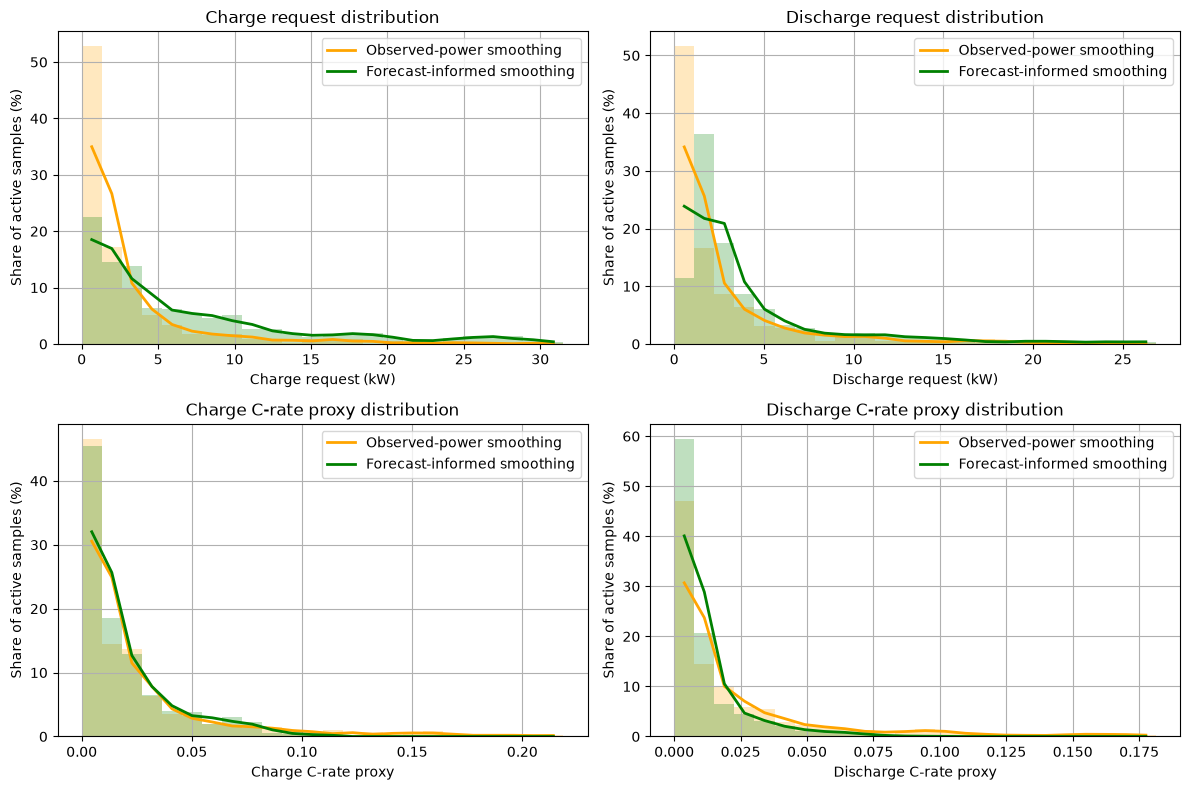

Saved battery replay input profiles and distribution figure:

* `../outputs/notebook_06/representative_bess_replay_profiles.parquet`
* `../outputs/notebook_06/selected_bess_replay_profiles.parquet`
* `../outputs/figures/notebook_06/replay_request_and_c_rate_distributions.png`

In [6]:
BATTERY_REPLAY_DT_SECONDS = int(TIME_STEP_HOURS * 3600)

sizing_merge_cols = [
    "scenario",
    "power_rating_kw",
    "nominal_energy_capacity_kwh",
    "usable_energy_available_kwh",
    "soc_min",
    "soc_max",
    "reference_soc",
]


representative_replay_profiles = representative_segment.merge(
    bess_sizing_assumptions[sizing_merge_cols],
    on="scenario",
    how="left",
)

representative_replay_profiles["p_bess_request_kw"] = (
    representative_replay_profiles["p_st_kw"]
)

representative_replay_profiles["p_bess_request_w"] = (
    representative_replay_profiles["p_bess_request_kw"] * 1000
)

representative_replay_profiles["dt_seconds"] = BATTERY_REPLAY_DT_SECONDS

representative_replay_profiles["charge_c_rate_proxy"] = (
    representative_replay_profiles["p_bess_request_kw"].clip(lower=0)
    / representative_replay_profiles["nominal_energy_capacity_kwh"]
)

representative_replay_profiles["discharge_c_rate_proxy"] = (
    -representative_replay_profiles["p_bess_request_kw"].clip(upper=0)
    / representative_replay_profiles["nominal_energy_capacity_kwh"]
)


all_replay_profiles = selected_timeseries.merge(
    bess_sizing_assumptions[sizing_merge_cols],
    on="scenario",
    how="left",
)

all_replay_profiles["p_bess_request_kw"] = all_replay_profiles["p_st_kw"]
all_replay_profiles["p_bess_request_w"] = all_replay_profiles["p_bess_request_kw"] * 1000
all_replay_profiles["dt_seconds"] = BATTERY_REPLAY_DT_SECONDS

all_replay_profiles["charge_c_rate_proxy"] = (
    all_replay_profiles["p_bess_request_kw"].clip(lower=0)
    / all_replay_profiles["nominal_energy_capacity_kwh"]
)

all_replay_profiles["discharge_c_rate_proxy"] = (
    -all_replay_profiles["p_bess_request_kw"].clip(upper=0)
    / all_replay_profiles["nominal_energy_capacity_kwh"]
)


representative_replay_path = (
    NOTEBOOK_OUTPUT_DIR
    / "representative_bess_replay_profiles.parquet"
)

all_replay_profiles_path = (
    NOTEBOOK_OUTPUT_DIR
    / "selected_bess_replay_profiles.parquet"
)

representative_replay_profiles.to_parquet(representative_replay_path, index=False)
all_replay_profiles.to_parquet(all_replay_profiles_path, index=False)


replay_input_summary = (
    representative_replay_profiles
    .groupby(["scenario", "scenario_name"], observed=True)
    .agg(
        n_samples=("target_time", "size"),
        duration_days=("dt_seconds", lambda s: s.sum() / (24 * 3600)),
        max_charge_request_kw=("p_bess_request_kw", lambda s: s.clip(lower=0).max()),
        max_discharge_request_kw=("p_bess_request_kw", lambda s: abs(s.clip(upper=0).min())),
        mean_charge_c_rate_proxy=("charge_c_rate_proxy", "mean"),
        p95_charge_c_rate_proxy=("charge_c_rate_proxy", lambda s: s.quantile(0.95)),
        max_charge_c_rate_proxy=("charge_c_rate_proxy", "max"),
        mean_discharge_c_rate_proxy=("discharge_c_rate_proxy", "mean"),
        p95_discharge_c_rate_proxy=("discharge_c_rate_proxy", lambda s: s.quantile(0.95)),
        max_discharge_c_rate_proxy=("discharge_c_rate_proxy", "max"),
    )
    .reset_index()
)

replay_input_display = replay_input_summary.copy()

numeric_cols = replay_input_display.select_dtypes(include="number").columns
replay_input_display[numeric_cols] = replay_input_display[numeric_cols].round(3)

replay_input_display.columns = (
    replay_input_display.columns
    .str.replace("_", " ", regex=False)
)

display(Markdown(replay_input_display.to_markdown(index=False)))


distribution_grid_path = FIGURES_DIR / "replay_request_and_c_rate_distributions.png"

plot_replay_distribution_grid(
    df=all_replay_profiles,
    output_path=distribution_grid_path,
    scenario_color_map=SCENARIO_COLOR_MAP,
)

display(
    Markdown(
        "Saved battery replay input profiles and distribution figure:\n\n"
        f"* `{representative_replay_path}`\n"
        f"* `{all_replay_profiles_path}`\n"
        f"* `{distribution_grid_path}`"
    )
)

The representative segment shows relatively modest battery power intensity under the simple sizing assumptions used here. For the detailed 9.9-day segment, the observed-power smoothing case reaches about 11.4 kW charge request and 8.6 kW discharge request, while the forecast-informed case reaches about 16.6 kW charge request and 13.5 kW discharge request. The corresponding C-rate proxies remain low because the assumed nominal battery capacities are sized conservatively from the maximum fold-level energy requirements.

Across all selected fold and segment replay profiles, most active charge and discharge samples are concentrated near low power requests and low C-rate proxies. The long right tails indicate that occasional higher-intensity charge or discharge events are still present. These tail events are important for later interpretation because they can contribute disproportionately to battery stress, even when the typical operating point is mild.

The forecast-informed smoothing profile shows a somewhat broader request distribution than the observed-power smoothing profile, especially on the charge side. This is consistent with the earlier storage-smoothing results: forecast-informed smoothing can create larger storage mismatch when the smoothed grid target follows forecasted rather than observed WEC power. These distributions should be read as screening indicators of the requested duty cycle, not as final degradation results.